# Download and Setup PySpark

In [1]:
# 1. Update package list and install Java 8
!apt-get update
!apt-get install openjdk-8-jdk-headless -qq > /dev/null

# 2. Download and extract Spark 3.5.3 (Compatible with current Python versions)
!wget -q https://archive.apache.org/dist/spark/spark-3.5.3/spark-3.5.3-bin-hadoop3.tgz
!tar xf spark-3.5.3-bin-hadoop3.tgz

# 3. Install findspark
!pip install -q findspark

# 4. Set the correct environment variables for Spark 3.5.3
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.3-bin-hadoop3"

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [2]:
# !apt-get update # Update apt-get repository.
# !apt-get install openjdk-8-jdk-headless -qq > /dev/null # Install Java.
# !wget -q http://archive.apache.org/dist/spark/spark-3.1.1/spark-3.1.1-bin-hadoop3.2.tgz # Download Apache Sparks.
# !tar xf spark-3.1.1-bin-hadoop3.2.tgz # Unzip the tgz file.
# !pip install -q findspark # Install findspark. Adds PySpark to the System path during runtime.


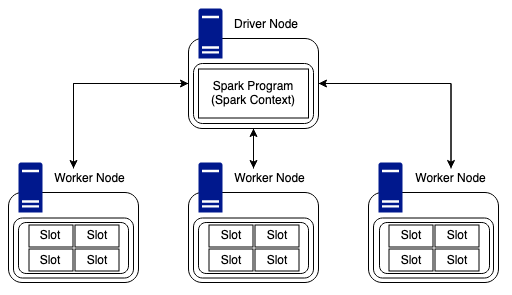

In [3]:
# import os
# os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
# os.environ["SPARK_HOME"] = "/content/spark-3.1.1-bin-hadoop3.2"

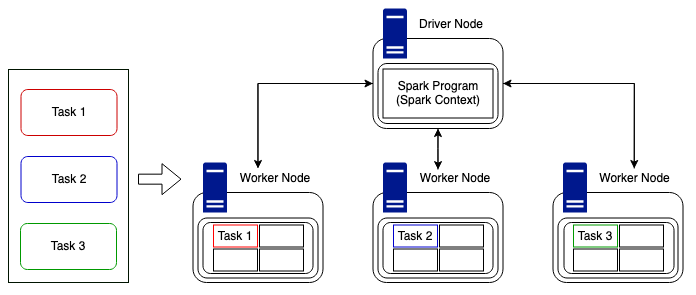

## Texts Analytics on PySpark

In [4]:
# Initialize findspark
import findspark
findspark.init()

# Create a PySpark session
from pyspark.sql import SparkSession
spark = SparkSession.builder.master("local[*]").getOrCreate()
spark

Download dataset at https://www.kaggle.com/datasets/kazanova/sentiment140 <br>
This is the sentiment140 dataset. It contains 1,600,000 tweets extracted using the twitter api. <br>
The tweets have been annotated (0 = negative, 4 = positive) and they can be used to detect sentiment.

| Field  | Description                                                                               | Example                                |
|--------|-------------------------------------------------------------------------------------------|----------------------------------------|
| target | the polarity of the tweet (0 = negative, 2 = neutral, 4 = positive)                       | 0                                      |
| ids    | The id of the tweet                                                                       | 2087                                   |
| date   | the date of the tweet                                                                     | Sat May 16 23:58:44 UTC 2009           |
| flag   | The query (lyx). If there is no query, then this value is NO_QUERY.                       | lyx                                    |
| user   | the user that tweeted                                                                     | robotickilldozr                        |
| text   | the text of the tweet                                                                     | Lyx is cool                            |


In [5]:
# Load the tweets data into RDD using the spark session's sparkContext
rdd_tweets = spark.sparkContext.textFile("/content/training.1600000.processed.noemoticon.csv")

In [6]:
# To view  / get the first five row objects
rdd_tweets.take(5)

['"0","1467810369","Mon Apr 06 22:19:45 PDT 2009","NO_QUERY","_TheSpecialOne_","@switchfoot http://twitpic.com/2y1zl - Awww, that\'s a bummer.  You shoulda got David Carr of Third Day to do it. ;D"',
 '"0","1467810672","Mon Apr 06 22:19:49 PDT 2009","NO_QUERY","scotthamilton","is upset that he can\'t update his Facebook by texting it... and might cry as a result  School today also. Blah!"',
 '"0","1467810917","Mon Apr 06 22:19:53 PDT 2009","NO_QUERY","mattycus","@Kenichan I dived many times for the ball. Managed to save 50%  The rest go out of bounds"',
 '"0","1467811184","Mon Apr 06 22:19:57 PDT 2009","NO_QUERY","ElleCTF","my whole body feels itchy and like its on fire "',
 '"0","1467811193","Mon Apr 06 22:19:57 PDT 2009","NO_QUERY","Karoli","@nationwideclass no, it\'s not behaving at all. i\'m mad. why am i here? because I can\'t see you all over there. "']

#### Process the tweets by using `.map()`

In [7]:
def process_string(s):
    split = s.split(',') # Split the string by ','
    if len(split) != 6:
        split[5] = ''.join(split[5:])
        split = split[:6]

    for i in range(6):
        split[i] = split[i][1:-1]
    return split
rdd_tweets1 = rdd_tweets.map(lambda s: process_string(s))
rdd_tweets1.take(5)

[['0',
  '1467810369',
  'Mon Apr 06 22:19:45 PDT 2009',
  'NO_QUERY',
  '_TheSpecialOne_',
  "@switchfoot http://twitpic.com/2y1zl - Awww that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D"],
 ['0',
  '1467810672',
  'Mon Apr 06 22:19:49 PDT 2009',
  'NO_QUERY',
  'scotthamilton',
  "is upset that he can't update his Facebook by texting it... and might cry as a result  School today also. Blah!"],
 ['0',
  '1467810917',
  'Mon Apr 06 22:19:53 PDT 2009',
  'NO_QUERY',
  'mattycus',
  '@Kenichan I dived many times for the ball. Managed to save 50%  The rest go out of bounds'],
 ['0',
  '1467811184',
  'Mon Apr 06 22:19:57 PDT 2009',
  'NO_QUERY',
  'ElleCTF',
  'my whole body feels itchy and like its on fire '],
 ['0',
  '1467811193',
  'Mon Apr 06 22:19:57 PDT 2009',
  'NO_QUERY',
  'Karoli',
  "@nationwideclass no it's not behaving at all. i'm mad. why am i here? because I can't see you all over there. "]]

In [9]:
# Get the number of row objects or twets
rdd_tweets1.count() # Takes time -->  PySpark needs to read all partitions of the RDD and aggregate the counts, which can be slow for large datasets

1600000

#### Transform it to structured data

In [11]:
# What should be the columns of the data frame?
deptColumns = ["target", "ids", "date", "flag", "user", "text"]

# Create data frame using the column names list
tweetsDF = rdd_tweets1.toDF(deptColumns)

In [13]:
tweetsDF.printSchema()

root
 |-- target: string (nullable = true)
 |-- ids: string (nullable = true)
 |-- date: string (nullable = true)
 |-- flag: string (nullable = true)
 |-- user: string (nullable = true)
 |-- text: string (nullable = true)



In [14]:
tweetsDF.show(truncate=True)

+------+----------+--------------------+--------+---------------+--------------------+
|target|       ids|                date|    flag|           user|                text|
+------+----------+--------------------+--------+---------------+--------------------+
|     0|1467810369|Mon Apr 06 22:19:...|NO_QUERY|_TheSpecialOne_|@switchfoot http:...|
|     0|1467810672|Mon Apr 06 22:19:...|NO_QUERY|  scotthamilton|is upset that he ...|
|     0|1467810917|Mon Apr 06 22:19:...|NO_QUERY|       mattycus|@Kenichan I dived...|
|     0|1467811184|Mon Apr 06 22:19:...|NO_QUERY|        ElleCTF|my whole body fee...|
|     0|1467811193|Mon Apr 06 22:19:...|NO_QUERY|         Karoli|@nationwideclass ...|
|     0|1467811372|Mon Apr 06 22:20:...|NO_QUERY|       joy_wolf|@Kwesidei not the...|
|     0|1467811592|Mon Apr 06 22:20:...|NO_QUERY|        mybirch|         Need a hug |
|     0|1467811594|Mon Apr 06 22:20:...|NO_QUERY|           coZZ|@LOLTrish hey  lo...|
|     0|1467811795|Mon Apr 06 22:20:...|NO_

#### Selecting tweets by a user

We select all the tweets by this user : starkissed

In [16]:
# Select-Where query (selecting all the tweets of user ) [ Seeing the dates on which the user tweeted]
tweetsDF.where(tweetsDF.user == "starkissed").select(tweetsDF.date).collect()

[Row(date='Mon Apr 06 22:20:31 PDT 2009'),
 Row(date='Fri May 01 23:36:21 PDT 2009'),
 Row(date='Sun May 10 19:35:12 PDT 2009'),
 Row(date='Mon May 18 05:57:55 PDT 2009'),
 Row(date='Fri May 29 09:28:23 PDT 2009'),
 Row(date='Fri May 29 16:40:47 PDT 2009'),
 Row(date='Fri May 29 17:14:18 PDT 2009'),
 Row(date='Sat May 30 06:45:57 PDT 2009'),
 Row(date='Sat May 30 09:35:11 PDT 2009'),
 Row(date='Sun May 31 13:30:47 PDT 2009'),
 Row(date='Tue Jun 02 10:24:34 PDT 2009'),
 Row(date='Wed Jun 03 04:26:07 PDT 2009'),
 Row(date='Fri Jun 05 11:58:06 PDT 2009'),
 Row(date='Mon Jun 15 13:45:23 PDT 2009'),
 Row(date='Mon Jun 15 19:52:47 PDT 2009'),
 Row(date='Mon Jun 15 19:58:11 PDT 2009'),
 Row(date='Mon Jun 15 20:07:56 PDT 2009'),
 Row(date='Tue Jun 16 10:54:52 PDT 2009'),
 Row(date='Tue Jun 16 13:27:11 PDT 2009'),
 Row(date='Tue Jun 16 15:58:45 PDT 2009'),
 Row(date='Tue Jun 16 16:02:00 PDT 2009'),
 Row(date='Tue Jun 16 16:29:21 PDT 2009'),
 Row(date='Wed Jun 17 18:09:47 PDT 2009'),
 Row(date='

#### Let see these on a Graph

In [17]:
import networkx as nx
import matplotlib.pyplot as plt

In [18]:
# Creating a graph with nodes and edges
G = nx.Graph()

G.add_node(234)
G.add_node("hello")
G.add_edge(234,"hello")

print("Nodes:", G.nodes())
print("Edges:", G.edges())

Nodes: [234, 'hello']
Edges: [(234, 'hello')]


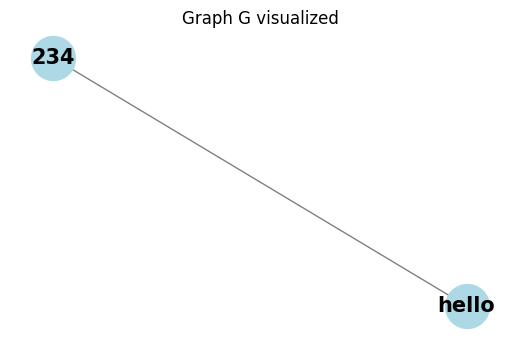

In [19]:
# Plot networkx graph
def plot_G(G, seed=42):
    plt.figure(figsize=(5, 3))
    pos = nx.spring_layout(G, seed=seed)  # Using spring layout AND a seed for reproducibility
    nx.draw(G, pos, with_labels=True, node_color='lightblue', font_weight='bold', font_size=15, node_size=1000, edge_color='gray')
    plt.title("Graph G visualized")
    plt.show()
plot_G(G)

In [20]:
# Accessing the neighbors
print(...) # Node 234s neighbor
print(...) # Node Hellos neighbor

Ellipsis
Ellipsis


#### How to add edge attributes

In [21]:
# Add an edge between the nodes "Alice" and "Bob" with attributes know and friends. The edge attributes are stored in a dictionary.
G.add_edge('Alice', 'Bob', know= 10, friends=5)

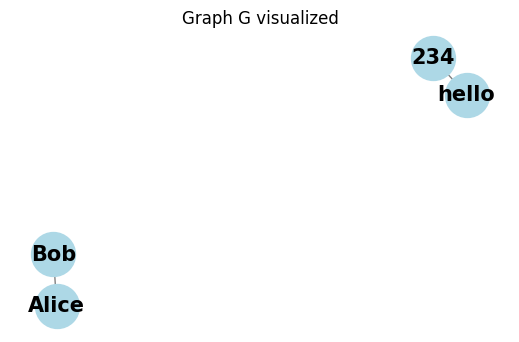

In [22]:
plot_G(G)

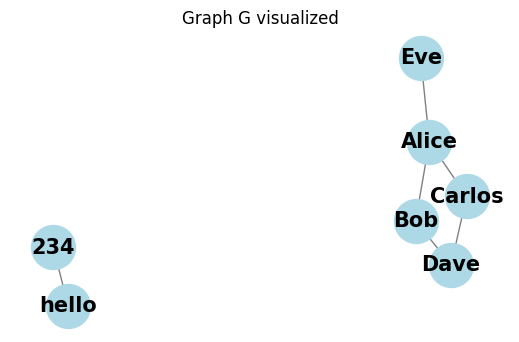

In [23]:
# Add more nodes
G.add_edge('Alice', 'Carlos')
G.add_edge('Carlos', 'Dave')
G.add_edge('Dave', 'Bob')
G.add_edge('Alice', 'Eve')
plot_G(G,seed=12)

#### Analyze graphs

In [25]:
# How many people does Bob know ?
nx.degree(G, 'Bob')

2

In [26]:
# Can Eve be introduced ot Dave ? If yes how (whats the easiest way)
nx.has_path(G,'Eve','Dave')

True

In [27]:
# Easiest way
nx.shortest_path(G,'Eve','Dave')

['Eve', 'Alice', 'Carlos', 'Dave']

#### Lets connect graphs and Twitter data

In [28]:
import re
wordTokenizerRegex = re.compile("[ ,.;]")

# Split to words and flatten using flatMap (to have one big RDD with all words). Then, we filter only hashtags (starting with "#")
hashTags = rdd_tweets1.flatMap(lambda xs: [x.split(' ') for x in xs]).flatMap(lambda x: x).filter(lambda w: w.startswith("#"))

In [29]:
""" Running cell takes time """
# how many hashtags did we find
print(hashTags.count())

# examine the first 100
print(hashTags.take(100))

44108
['#itm', '#therapyfail', '#fb', '#TTSC?', '#24', '#gayforpeavy', '#FML', '#3', '#camerafail', '#', '#...We', '#fb', '#travian', '#wow', '#art', '#fail', '#KrispyKreme', '#fb', '#24', '#the', '#twitter', '#fail', '#CNN', '#1', '#Kulula', '#surface', '#c25k', '#drupal', '#epicfail', '#rails', '#mhbigcatch', '#stuckrecord', '#twitteriffic', '#startrek', '#earthquake', '#php', '#poken', '#error', '#tracy', '#fb', '#dwsr', '#Italy', '#Earthquake', '#fantasysurfer', '#titsuptuesday', '#N85', '#heyxboxlive', '#House', '#babypunch', '#cob', '#ticket', '#fb', '#fb', '#terremoto', '#earthquake', '#italy', '#fail', '#&amp;$(#&amp;$!(@#$(!@#*$(#!(', '#@&amp;$(!@#($*(!@#*$(!@#&amp;$(!@#$&amp;!(@#!#@($...', '#itm', '#AutomationAtaCost', '#gsoc', '#rockbox', '#niceweather', '#Berlin', '#goodlife', '#Ambients', '#theinbetweeners', '#Twilight', '#Summers', '#mmuk09', '#i36', '#spotify', '#fb', '#pman', '#spbpuk', '#dreams', '#dreams', '#dwsr', '#fb', '#wolframalpha', '#search', '#semantic-web', '

In [30]:
# count unique words and sort them in descending order of count
countedHashTags = hashTags.map(lambda w: (w, 1)).reduceByKey(lambda a, b: a + b).sortBy(lambda tup: tup[1], ascending = False)

In [31]:
""" Running cell takes time """
#show top 100 words
countedHashTags.take(100)

[('#followfriday', 1861),
 ('#fb', 1728),
 ('#squarespace', 843),
 ('#FF', 503),
 ('#seb-day', 498),
 ('#', 485),
 ('#FollowFriday', 414),
 ('#1', 403),
 ('#musicmonday', 385),
 ('#iranelection', 342),
 ('#ff', 334),
 ('#fail', 288),
 ('#BSB', 273),
 ('#iremember', 263),
 ('#myweakness', 260),
 ('#asot400', 254),
 ('#marsiscoming', 245),
 ('#mcflyforgermany', 230),
 ('#2', 228),
 ('#andyhurleyday', 187),
 ('#inaperfectworld', 177),
 ('#iPhone', 175),
 ('#delongeday', 165),
 ('#haveyouever', 164),
 ('#f1', 163),
 ('#mileymonday', 155),
 ('#trackle', 153),
 ('#tcot', 151),
 ('#spymaster', 149),
 ('#bgt', 146),
 ('#e3', 126),
 ('#iphone', 122),
 ('#followfriday!', 120),
 ('#IranElection', 112),
 ('#E3', 111),
 ('#hhrs', 105),
 ('#clothdiapers', 104),
 ('#dontyouhate', 102),
 ('#goodsex', 102),
 ('#bradiewebb', 102),
 ('#mmwanted', 97),
 ('#flylady', 94),
 ("#tag'", 92),
 ('#asylm', 91),
 ('#BGT', 89),
 ('#chesterday', 87),
 ('#F1', 86),
 ('#hoppusday', 84),
 ('#andyclemmensen', 84),
 ('#e

#### Filter tweets with #musicmonday

In [33]:
tweetsDF.createOrReplaceTempView("tweets") # Create a view / temporary table for filtered tweets

In [34]:
temp_df = spark.sql("SELECT * FROM tweets WHERE LOWER(text) LIKE '%#musicmonday%'")
temp_df = temp_df.toPandas()
temp_df.head()

,target,ids,date,flag,user,text
0,0,1565096048,Mon Apr 20 05:53:13 PDT 2009,NO_QUERY,_whatshername,wanted to post Butch Walker's &quot;#1 Summer ...
1,0,1565528649,Mon Apr 20 06:58:21 PDT 2009,NO_QUERY,breezydayz,Listening to some Morningwood &quot;Sugarbaby&...
2,0,1833334416,Sun May 17 22:58:17 PDT 2009,NO_QUERY,dimabm,yay for #musicmonday !!! Too bad I can't tweet...
3,0,1833583078,Sun May 17 23:45:36 PDT 2009,NO_QUERY,Galiiit,#musicmonday Green Day 21st Century Breakdown....
4,0,1833589369,Sun May 17 23:46:51 PDT 2009,NO_QUERY,SketchStudios,@MyMelodie Thats a bummer for people who have ...


In [35]:
temp_df.to_csv("musicmonday.csv") # Once we have the required dataframe - we save it (to avoid having to re-run spark again next time)

#### Processing tweets to get mentioned users

In [36]:
# Example : Processing a tweet to get mentioned names
x = 'xyz @hot @cold " , '
# t = x.split()
# t = [word.strip(""" ,.:'\";""").lower() for word in t]
# print([word for word in t if word.startswith("@")])

In [37]:
def addMentionedColumn(df):

    def mentionsList(txt):
        allWords = [word.strip(""" ,.:'\";""").lower() for word in txt.split()]
        allNames = [word.strip("@") for word in allWords if word.startswith("@")]
        uniqueNames = list(set(allNames))
        return uniqueNames

    df["mentioned"] = df["text"].apply(mentionsList)

In [38]:
addMentionedColumn(temp_df)

In [39]:
temp_df.head(10)

,target,ids,date,flag,user,text,mentioned
0,0,1565096048,Mon Apr 20 05:53:13 PDT 2009,NO_QUERY,_whatshername,wanted to post Butch Walker's &quot;#1 Summer ...,[]
1,0,1565528649,Mon Apr 20 06:58:21 PDT 2009,NO_QUERY,breezydayz,Listening to some Morningwood &quot;Sugarbaby&...,[]
2,0,1833334416,Sun May 17 22:58:17 PDT 2009,NO_QUERY,dimabm,yay for #musicmonday !!! Too bad I can't tweet...,[]
3,0,1833583078,Sun May 17 23:45:36 PDT 2009,NO_QUERY,Galiiit,#musicmonday Green Day 21st Century Breakdown....,[]
4,0,1833589369,Sun May 17 23:46:51 PDT 2009,NO_QUERY,SketchStudios,@MyMelodie Thats a bummer for people who have ...,[mymelodie]
5,0,1834974520,Mon May 18 04:46:48 PDT 2009,NO_QUERY,acchanosaurus,#musicmonday now listening to @katyperry - thi...,[katyperry]
6,0,1835193221,Mon May 18 05:23:20 PDT 2009,NO_QUERY,piroteknix,I'd really like to say I'm not listening to NI...,[]
7,0,1835316387,Mon May 18 05:42:13 PDT 2009,NO_QUERY,carmelabalboa,I Really Want You - James Blunt #musicmonday T...,[]
8,0,1835708717,Mon May 18 06:35:11 PDT 2009,NO_QUERY,GlmmC,workingworking working need a holiday!!! #mus...,[]
9,0,1835998304,Mon May 18 07:10:25 PDT 2009,NO_QUERY,samuy,#musicmonday NO MONDAY playlist yet. [suggest...,[]


In [40]:
def mentionGraph(df):
    g = nx.Graph()

    for  (index, target, ids, date, flag, user, text, mentionedUsers) in df.itertuples():
        for mentionedUser in mentionedUsers:
            if (user in g) and (mentionedUser in g[user]):
                g[user][mentionedUser]["numberMentions"] += 1
            else:
                g.add_edge(user, mentionedUser, numberMentions=1)

    return g

In [41]:
musicGraph = mentionGraph(temp_df)

In [42]:
print("# nodes:", len(musicGraph.nodes()))
print("# edges:", len(musicGraph.edges()))

# nodes: 173
# edges: 98


In [43]:
musicGraph['SketchStudios']

AtlasView({'mymelodie': {'numberMentions': 1}})

In [44]:
musicGraph['acchanosaurus']

AtlasView({'katyperry': {'numberMentions': 1}})

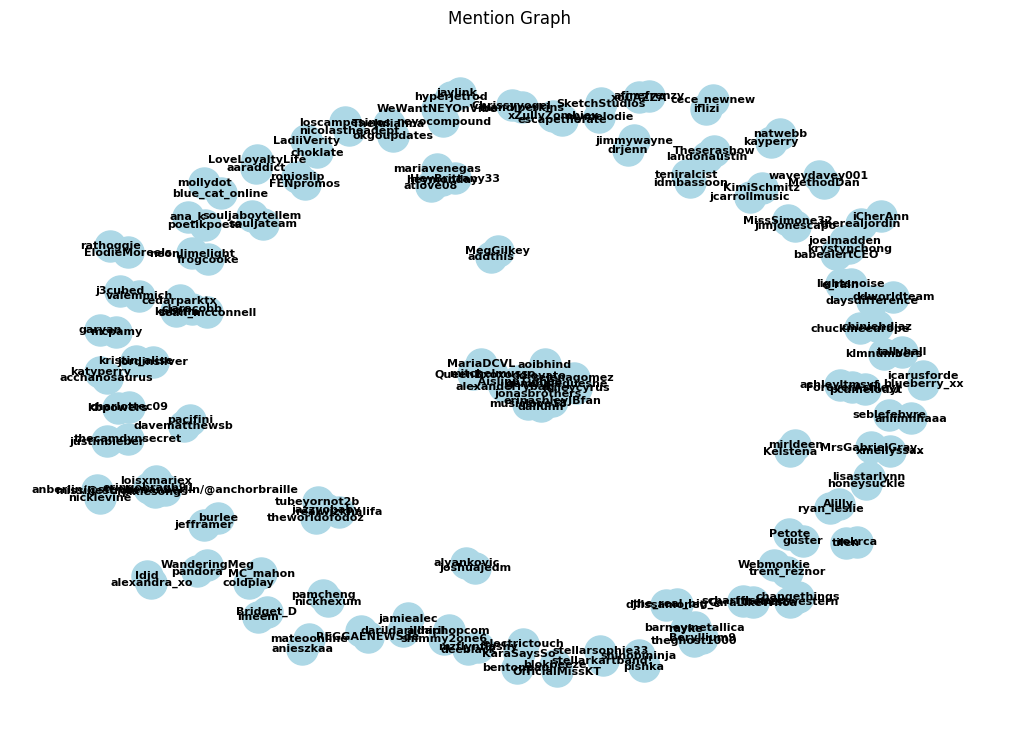

In [45]:
def plot_graph(g):
    plt.figure(figsize=(10, 7))
    pos = nx.spring_layout(g, seed=42)  # Use spring layout with a seed for reproducibility
    edges = g.edges(data=True)
    edge_labels = {(u, v): data['numberMentions'] for u, v, data in edges}

    nx.draw(g, pos, with_labels=True, node_color='lightblue', font_weight='bold', node_size=500, font_size=8, edge_color='gray')
    nx.draw_networkx_edge_labels(g, pos, edge_labels=edge_labels)

    plt.title("Mention Graph")
    plt.show()
# Plot the graph
plot_graph(musicGraph)

#### Interactive visuazlization

In [ ]:
!pip install pyvis

In [49]:
from pyvis.network import Network

def plot_interactive_graph(g):
    net = Network(notebook=True, width='100%', height='800px')
    for node in g.nodes:
        net.add_node(node, label=node, title=node)
    for edge in g.edges(data=True):
        user, mentionedUser, attrs = edge
        net.add_edge(user, mentionedUser, value=attrs['numberMentions'], title=f"Mentions: {attrs['numberMentions']}")

    net.show("interactive_mention_graph.html")

plot_interactive_graph(musicGraph)

interactive_mention_graph.html
